In [132]:
import re
import os

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Reading files from the directory

In [133]:
for dirname, _, filenames in os.walk('./input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_elu_loss_accuracy.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_elu_loss_accuracy_quantized.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_gelu_loss_accuracy.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_gelu_loss_accuracy_quantized.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_leakyrelu_loss_accuracy.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_leakyrelu_loss_accuracy_quantized.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_normalized_loss_accuracy.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_normalized_loss_accuracy_quantized.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_relu6_loss_accuracy.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_relu6_loss_accuracy_quantized.csv
./input\for_analysis\results_synthetic\loss_accuracy\acrgnn_relu_loss_accuracy.csv
./input\for_ana

## [Reading data] Creating a file_path variable for convenience 

In [134]:
file_path = "./input/for_analysis/results_synthetic/training_times/"

## [Reading data] Creating a file_name variable for convenience 

In [135]:
file_name="_training_time.csv"
file_name_quantized="_training_time_quantized.csv"

# Function for writing keys

In [136]:
def print_keys(key):
    latex_map = {
        "p1": r"$p1: \alpha_1(x) := \exists^{[8,10]}y\left(\alpha_0(y) \wedge \neg E(x,y)\right)$",
        "p2": r"$p2: \alpha_2(x) := \exists^{[10,30]}y\left(\alpha_1(y) \wedge \neg E(x,y)\right)$",
        "p3": r"$p3: \alpha_3(x) := \exists^{[10,30]}y\left(\alpha_2(y) \wedge \neg E(x,y)\right)$"
    }
    clean_latex = re.sub(r'[\x00-\x1F\x7F]', '', latex_map.get(key, ''))
    return clean_latex

## Comparing Activation Functions

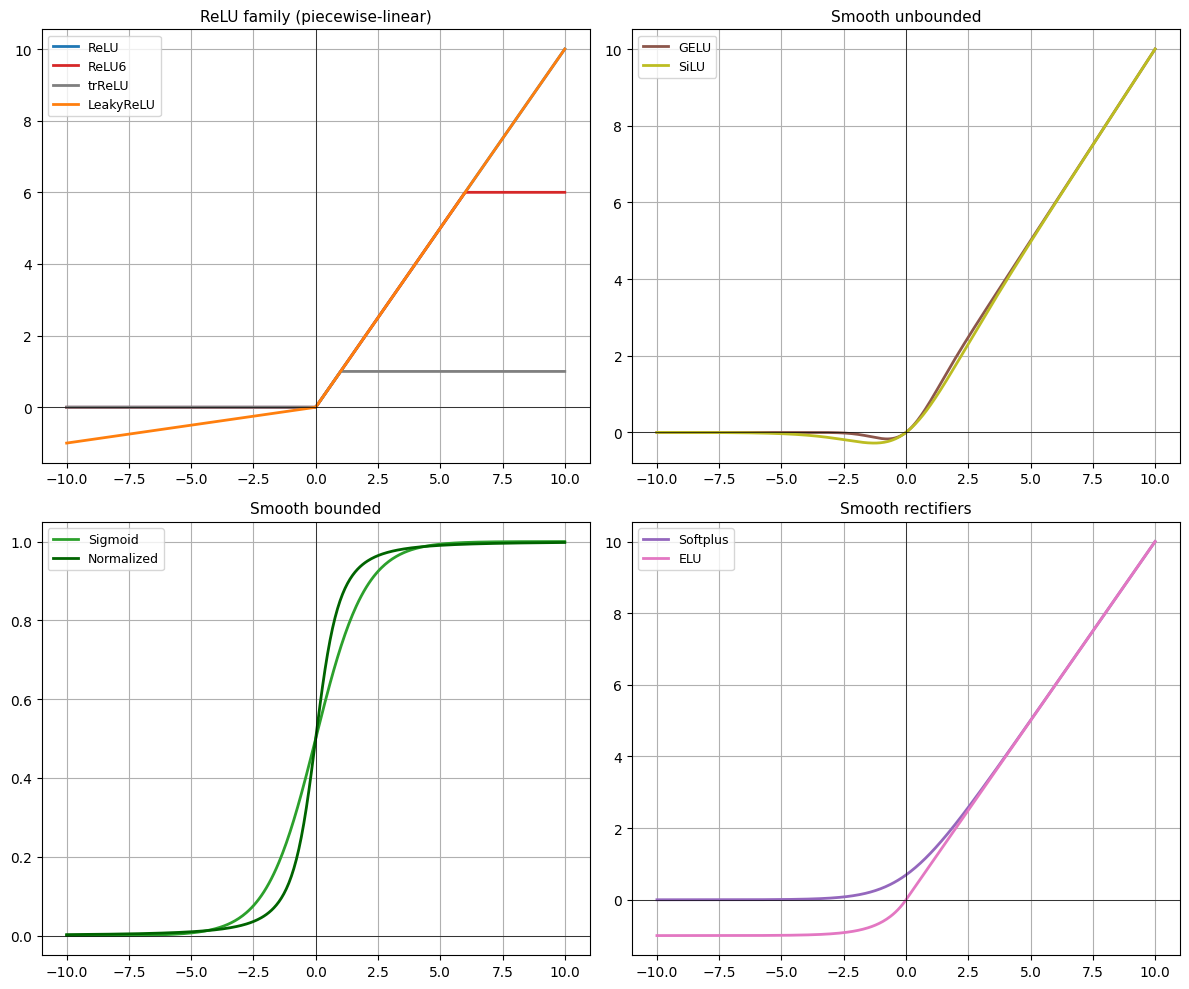

In [137]:
# Input range
x = torch.linspace(-10, 10, 400)

# Normalized activation (0,1)
def normalized(x):
    return (1.0 + x / torch.sqrt(1.0 + x * x)) / 2.0

# Grouped activations
groups = {
    "ReLU family (piecewise-linear)": [
        ("ReLU", nn.ReLU(), "tab:blue"),
        ("ReLU6", nn.ReLU6(), "tab:red"),
        ("trReLU", nn.Hardtanh(0, 1), "tab:gray"),
        ("LeakyReLU", nn.LeakyReLU(0.1), "tab:orange"),
    ],
    "Smooth unbounded": [
        ("GELU", nn.GELU(), "tab:brown"),
        ("SiLU", nn.SiLU(), "tab:olive"),
    ],
    "Smooth bounded": [
        ("Sigmoid", nn.Sigmoid(), "tab:green"),
        ("Normalized", normalized, "darkgreen"),
    ],
    "Smooth rectifiers": [
        ("Softplus", nn.Softplus(), "tab:purple"),
        ("ELU", nn.ELU(), "tab:pink"),
    ],
}

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each group
for ax, (title, acts) in zip(axes, groups.items()):
    for name, func, color in acts:
        y = func(x) if callable(func) else func(x)
        ax.plot(x.numpy(), y.detach().numpy(), label=name, color=color, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(True)
    ax.legend(fontsize=9)

plt.tight_layout()
#plt.savefig("activation_families_2x2.png", dpi=300)
plt.show()


# Training Time - Original

##  [Training time- Original]. Read the dataset and create a dataframe. Pattern:  df_{name_of_csv_file}

In [138]:
df_acrgnn_relu=pd.read_csv(f'{file_path}acrgnn_relu{file_name}')

df_acrgnn_relu6=pd.read_csv(f'{file_path}acrgnn_relu6{file_name}')

df_acrgnn_trrelu=pd.read_csv(f'{file_path}acrgnn_trrelu{file_name}')

df_acrgnn_leakyrelu=pd.read_csv(f'{file_path}acrgnn_leakyrelu{file_name}')

df_acrgnn_gelu=pd.read_csv(f'{file_path}acrgnn_gelu{file_name}')

df_acrgnn_silu=pd.read_csv(f'{file_path}acrgnn_silu{file_name}')

df_acrgnn_sigmoid=pd.read_csv(f'{file_path}acrgnn_sigmoid{file_name}')

df_acrgnn_normalized=pd.read_csv(f'{file_path}acrgnn_normalized{file_name}')

df_acrgnn_softplus=pd.read_csv(f'{file_path}acrgnn_softplus{file_name}')

df_acrgnn_elu=pd.read_csv(f'{file_path}acrgnn_elu{file_name}')

In [139]:
df_acrgnn_relu.head()

,activation_function,key,layer,hidden_dimension,learning_rate,time_taken_seconds
0,relu,p1,1,2,0.010,13.284794
1,relu,p1,1,2,0.001,12.981863
2,relu,p1,1,2,0.005,13.038484
3,relu,p1,2,2,0.010,13.703339
4,relu,p1,2,2,0.001,13.638661


In [140]:
dfs = [df_acrgnn_relu, df_acrgnn_relu6, df_acrgnn_trrelu, df_acrgnn_leakyrelu, df_acrgnn_gelu, df_acrgnn_silu, df_acrgnn_sigmoid, df_acrgnn_normalized, df_acrgnn_softplus, df_acrgnn_elu]

In [141]:
activation_map = {
    "relu": "ReLU",
    "relu6": "ReLU6",
    "trrelu": "trReLU",
    "leakyrelu": "LeakyReLU",
    "gelu": "GELU",
    "silu": "SiLU",
    "sigmoid": "Sigmoid",
    "normalized": "Normalized",
    "softplus": "Softplus",
    "elu": "ELU"
}

In [142]:
for df in dfs:
    df["activation_function"] = df["activation_function"].replace(activation_map)

In [143]:
df_acrgnn_relu.head()

,activation_function,key,layer,hidden_dimension,learning_rate,time_taken_seconds
0,ReLU,p1,1,2,0.010,13.284794
1,ReLU,p1,1,2,0.001,12.981863
2,ReLU,p1,1,2,0.005,13.038484
3,ReLU,p1,2,2,0.010,13.703339
4,ReLU,p1,2,2,0.001,13.638661


In [144]:
df_acrgnn_relu.learning_rate.unique()

array([0.01 , 0.001, 0.005])

##  [Training time- Original]. Combine activation functions to form one table

In [145]:
def combine_with_activation(dataframes):
    combined = []
    for df in dataframes:
        temp = df.copy()
        combined.append(temp[temp.columns])
    return pd.concat(combined, ignore_index=True)

In [146]:
combined_acrgnn_activationFunction = combine_with_activation(dfs)
combined_acrgnn_activationFunction.head()

,activation_function,key,layer,hidden_dimension,learning_rate,time_taken_seconds
0,ReLU,p1,1,2,0.010,13.284794
1,ReLU,p1,1,2,0.001,12.981863
2,ReLU,p1,1,2,0.005,13.038484
3,ReLU,p1,2,2,0.010,13.703339
4,ReLU,p1,2,2,0.001,13.638661


In [147]:
combined_acrgnn_activationFunction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   activation_function  9000 non-null   object 
 1   key                  9000 non-null   object 
 2   layer                9000 non-null   int64  
 3   hidden_dimension     9000 non-null   int64  
 4   learning_rate        9000 non-null   float64
 5   time_taken_seconds   9000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 422.0+ KB


##  [Training time- Original]. Plot Trainig time of activation function for different formulas

In [148]:
def plot_all_plotly(
    dataframe,
    activations="all",
    keys="all",
    h=2,
    lr=0.01,
    plottype="plot"
):
    round_decimals = 2

    if activations == "all":
        activations = ["ReLU", "ReLU6", "trReLU", "LeakyReLU",
                       "GELU", "SiLU", "Sigmoid",
                       "Normalized", "Softplus", "ELU"]

    if keys == "all":
        keys = ["p1", "p2", "p3"]

    # Create subplot structure
    fig = make_subplots(
        rows=1,
        cols=len(keys),
        shared_yaxes=True,
        subplot_titles=[f"Training Time — {print_keys(k)}" for k in keys]
    )

    for col_index, key in enumerate(keys, start=1):
        for activation in activations:

            df_filtered = dataframe[
                (dataframe["activation_function"] == activation) &
                (dataframe["key"] == key) &
                (dataframe["hidden_dimension"] == h) &
                (dataframe["learning_rate"] == lr)
            ].sort_values(by="layer")

            if df_filtered.empty:
                continue

            df_filtered["time_taken_seconds"] = \
                df_filtered["time_taken_seconds"].round(round_decimals)

            if plottype == "plot":

                fig.add_trace(
                    go.Scatter(
                        x=df_filtered["layer"],
                        y=df_filtered["time_taken_seconds"],
                        mode="lines+markers",
                        name=activation,
                        legendgroup=activation,
                        showlegend=(col_index == 1)
                    ),
                    row=1,
                    col=col_index
                )

            elif plottype == "bar":

                fig.add_trace(
                    go.Bar(
                        x=df_filtered["layer"],
                        y=df_filtered["time_taken_seconds"],
                        name=activation,
                        legendgroup=activation,
                        showlegend=(col_index == 1)
                    ),
                    row=1,
                    col=col_index
                )

        fig.update_xaxes(title_text="Number of Layers", row=1, col=col_index)

    fig.update_yaxes(title_text="Training Time (seconds)", row=1, col=1)

    fig.update_layout(
        title=f"Training Time per classifier (hidden dimension {h}, learning rate {lr})",
        height=500,
        width=1400,
        template="plotly_white",
        legend_title="Activation"
    )

    fig.show()

In [149]:
# for hiddendimension in [ 2,  4,  5,  6,  7,  8,  9, 10, 16, 32]:
    # for learningrate in [0.01 , 0.001, 0.005]:
        # plot_all_plotly(combined_acrgnn_activationFunction,activations='all',keys='all',h = hiddendimension,lr= learningrate,plottype='plot')

##  [Training time- Original]. Calculate Trainig time of activation function for different formulas

In [150]:
def totall_time_per_acctivation(dataframe):
    time_all = (
        dataframe.groupby(["key", "activation_function"], as_index=True)["time_taken_seconds"]
        .sum()
        .round(2)
        .reset_index()
    )
    activations = [
    "ReLU", "ReLU6", "trReLU", "LeakyReLU",
    "GELU", "SiLU", "Sigmoid", "Normalized",
    "Softplus", "ELU"
    ]
    table = time_all.pivot_table(index="key", columns="activation_function", values="time_taken_seconds", fill_value=0)
    table = table.reindex(columns=activations)

    table = table.reindex(["p1", "p2", "p3"], level="key")
    return table

In [151]:
df = combined_acrgnn_activationFunction.copy()
table=totall_time_per_acctivation(df)
table

activation_function,ReLU,ReLU6,trReLU,LeakyReLU,GELU,SiLU,Sigmoid,Normalized,Softplus,ELU
key,,,,,,,,,,
p1,4831.71,4861.24,4863.12,4860.25,4846.62,4853.88,4841.79,5037.88,4861.80,4860.28
p2,4843.09,4858.06,4860.35,4855.30,4849.57,4848.89,4851.51,5032.96,4859.86,4860.32
p3,4834.85,4856.53,4859.48,4857.82,4857.39,4853.81,4847.41,5039.38,4851.02,4855.93


In [152]:
latex_str = table.to_latex(
    index=True,
    float_format="%.2f",
    caption="Training time (s) per key and activation",
    label="tab:training-times"
)

# Replace hlines with booktabs rules
latex_str = latex_str.replace("\\hline", "\\midrule")
latex_str = latex_str.replace("\\toprule", "\\toprule\n")
latex_str = latex_str.replace("\\bottomrule", "\\bottomrule\n")

print(latex_str)

\begin{table}
\caption{Training time (s) per key and activation}
\label{tab:training-times}
\begin{tabular}{lrrrrrrrrrr}
\toprule

activation_function & ReLU & ReLU6 & trReLU & LeakyReLU & GELU & SiLU & Sigmoid & Normalized & Softplus & ELU \\
key &  &  &  &  &  &  &  &  &  &  \\
\midrule
p1 & 4831.71 & 4861.24 & 4863.12 & 4860.25 & 4846.62 & 4853.88 & 4841.79 & 5037.88 & 4861.80 & 4860.28 \\
p2 & 4843.09 & 4858.06 & 4860.35 & 4855.30 & 4849.57 & 4848.89 & 4851.51 & 5032.96 & 4859.86 & 4860.32 \\
p3 & 4834.85 & 4856.53 & 4859.48 & 4857.82 & 4857.39 & 4853.81 & 4847.41 & 5039.38 & 4851.02 & 4855.93 \\
\bottomrule

\end{tabular}
\end{table}



##  [Training time- Original]. Find the Slowest and Fastest Activation function for each layer

In [153]:
df = combined_acrgnn_activationFunction.copy()

group_cols = ["key", "layer", "hidden_dimension", "learning_rate"]

# index of min/max rows per group
idx_min = df.groupby(group_cols)["time_taken_seconds"].idxmin()
idx_max = df.groupby(group_cols)["time_taken_seconds"].idxmax()

winners = (
    df.loc[idx_min, group_cols + ["activation_function", "time_taken_seconds"]]
      .rename(columns={"activation_function": "best_af", "time_taken_seconds": "best_time_s"})
      .reset_index(drop=True)
)

losers = (
    df.loc[idx_max, group_cols + ["activation_function", "time_taken_seconds"]]
      .rename(columns={"activation_function": "worst_af", "time_taken_seconds": "worst_time_s"})
      .reset_index(drop=True)
)

summary = winners.merge(losers, on=group_cols)
summary["gap_s"] = summary["worst_time_s"] - summary["best_time_s"]
summary

,key,layer,hidden_dimension,learning_rate,best_af,best_time_s,worst_af,worst_time_s,gap_s
0,p1,1,2,0.001,ReLU,12.981863,ReLU6,13.774640,0.792777
1,p1,1,2,0.005,ReLU,13.038484,Sigmoid,14.159667,1.121183
2,p1,1,2,0.010,ReLU,13.284794,SiLU,14.197934,0.913141
3,p1,1,4,0.001,ReLU,13.293707,LeakyReLU,13.983132,0.689425
4,p1,1,4,0.005,ReLU6,13.294641,SiLU,14.486976,1.192335
...,...,...,...,...,...,...,...,...,...
895,p3,10,16,0.005,Softplus,18.528193,Normalized,19.767818,1.239625
896,p3,10,16,0.010,GELU,18.383739,ELU,22.039416,3.655678
897,p3,10,32,0.001,ReLU,18.776112,Normalized,19.927846,1.151734
898,p3,10,32,0.005,GELU,18.720489,Normalized,20.024364,1.303875


In [154]:
summary.best_af.unique()

array(['ReLU', 'ReLU6', 'SiLU', 'Sigmoid', 'trReLU', 'Softplus', 'ELU',
       'LeakyReLU', 'GELU'], dtype=object)

In [155]:
activations = [
    "ReLU", "ReLU6", "trReLU", "LeakyReLU",
    "GELU", "SiLU", "Sigmoid", "Normalized",
    "Softplus", "ELU"
]

win_counts = (
    summary.groupby(["key", "best_af"])
           .size()
           .rename("wins")
           .reset_index()
)

loss_counts = (
    summary.groupby(["key", "worst_af"])
           .size()
           .rename("losses")
           .reset_index()
)

win_pivot = (
    win_counts.pivot(index="key", columns="best_af", values="wins")
              .reindex(columns=activations)   # adds missing cols
              .fillna(0)                      # turn NaN -> 0 wins
              .astype(int)
)
loss_pivot = (
    loss_counts.pivot(index="key", columns="worst_af", values="losses")
              .reindex(columns=activations)   # adds missing cols
              .fillna(0)                      # turn NaN -> 0 wins
              .astype(int)
)

In [156]:
total_per_key = summary.groupby("key").size()
win_pct = (win_pivot.div(total_per_key, axis=0) * 100).round(1)

win_pct

best_af,ReLU,ReLU6,trReLU,LeakyReLU,GELU,SiLU,Sigmoid,Normalized,Softplus,ELU
key,,,,,,,,,,
p1,21.3,9.7,6.0,7.3,12.3,8.7,19.3,0.0,8.7,6.7
p2,12.7,7.7,8.7,8.3,13.3,15.0,11.7,0.0,10.7,12.0
p3,14.0,7.0,7.7,11.0,13.3,9.3,19.7,0.0,8.7,9.3


In [157]:
total_per_key = summary.groupby("key").size()
loss_pct = (loss_pivot.div(total_per_key, axis=0) * 100).round(1)

loss_pct

worst_af,ReLU,ReLU6,trReLU,LeakyReLU,GELU,SiLU,Sigmoid,Normalized,Softplus,ELU
key,,,,,,,,,,
p1,3.3,6.3,4.7,6.0,3.0,7.0,5.0,54.7,5.7,4.3
p2,3.3,4.3,7.7,4.0,4.7,4.7,5.3,55.7,5.3,5.0
p3,1.3,5.3,5.0,4.7,5.7,4.0,3.7,59.0,5.0,6.3


In [158]:
latex_str = win_pct.to_latex(
    index=True,
    float_format="%.2f",
    caption="Percentage of configurations in which each activation function achieves the minimum training time, aggregated over layers 1--10 and all tested hidden dimensions and learning rates.",
    label="tab:best:training-times"
)

# Replace hlines with booktabs rules
latex_str = latex_str.replace("\\hline", "\\midrule")
latex_str = latex_str.replace("\\toprule", "\\toprule\n")
latex_str = latex_str.replace("\\bottomrule", "\\bottomrule\n")

print(latex_str)

\begin{table}
\caption{Percentage of configurations in which each activation function achieves the minimum training time, aggregated over layers 1--10 and all tested hidden dimensions and learning rates.}
\label{tab:best:training-times}
\begin{tabular}{lrrrrrrrrrr}
\toprule

best_af & ReLU & ReLU6 & trReLU & LeakyReLU & GELU & SiLU & Sigmoid & Normalized & Softplus & ELU \\
key &  &  &  &  &  &  &  &  &  &  \\
\midrule
p1 & 21.30 & 9.70 & 6.00 & 7.30 & 12.30 & 8.70 & 19.30 & 0.00 & 8.70 & 6.70 \\
p2 & 12.70 & 7.70 & 8.70 & 8.30 & 13.30 & 15.00 & 11.70 & 0.00 & 10.70 & 12.00 \\
p3 & 14.00 & 7.00 & 7.70 & 11.00 & 13.30 & 9.30 & 19.70 & 0.00 & 8.70 & 9.30 \\
\bottomrule

\end{tabular}
\end{table}



In [159]:
latex_str = loss_pct.to_latex(
    index=True,
    float_format="%.2f",
    caption="Percentage of configurations in which each activation function achieves the maximum training time, aggregated over layers 1--10 and all tested hidden dimensions and learning rates.",
    label="tab:best:training-times"
)

# Replace hlines with booktabs rules
latex_str = latex_str.replace("\\hline", "\\midrule")
latex_str = latex_str.replace("\\toprule", "\\toprule\n")
latex_str = latex_str.replace("\\bottomrule", "\\bottomrule\n")

print(latex_str)

\begin{table}
\caption{Percentage of configurations in which each activation function achieves the maximum training time, aggregated over layers 1--10 and all tested hidden dimensions and learning rates.}
\label{tab:best:training-times}
\begin{tabular}{lrrrrrrrrrr}
\toprule

worst_af & ReLU & ReLU6 & trReLU & LeakyReLU & GELU & SiLU & Sigmoid & Normalized & Softplus & ELU \\
key &  &  &  &  &  &  &  &  &  &  \\
\midrule
p1 & 3.30 & 6.30 & 4.70 & 6.00 & 3.00 & 7.00 & 5.00 & 54.70 & 5.70 & 4.30 \\
p2 & 3.30 & 4.30 & 7.70 & 4.00 & 4.70 & 4.70 & 5.30 & 55.70 & 5.30 & 5.00 \\
p3 & 1.30 & 5.30 & 5.00 & 4.70 & 5.70 & 4.00 & 3.70 & 59.00 & 5.00 & 6.30 \\
\bottomrule

\end{tabular}
\end{table}



# Time taken for quantization and evaluation of the quantized model

##  [Time- dPTQ]. Read the datset and create a dataframe

In [160]:
df_acrgnn_relu_quantized=pd.read_csv(f'{file_path}acrgnn_relu{file_name_quantized}')

df_acrgnn_relu6_quantized=pd.read_csv(f'{file_path}acrgnn_relu6{file_name_quantized}')

df_acrgnn_trrelu_quantized=pd.read_csv(f'{file_path}acrgnn_trrelu{file_name_quantized}')

df_acrgnn_leakyrelu_quantized=pd.read_csv(f'{file_path}acrgnn_leakyrelu{file_name_quantized}')

df_acrgnn_gelu_quantized=pd.read_csv(f'{file_path}acrgnn_gelu{file_name_quantized}')

df_acrgnn_silu_quantized=pd.read_csv(f'{file_path}acrgnn_silu{file_name_quantized}')

df_acrgnn_sigmoid_quantized=pd.read_csv(f'{file_path}acrgnn_sigmoid{file_name_quantized}')

df_acrgnn_normalized_quantized=pd.read_csv(f'{file_path}acrgnn_normalized{file_name_quantized}')

df_acrgnn_softplus_quantized=pd.read_csv(f'{file_path}acrgnn_softplus{file_name_quantized}')

df_acrgnn_elu_quantized=pd.read_csv(f'{file_path}acrgnn_elu{file_name_quantized}')

In [161]:
df_acrgnn_relu_quantized.head()

,activation_function,key,layer,hidden_dimension,learning_rate,time_taken_seconds,bit
0,relu,p1,1,2,0.010,2.316513,8
1,relu,p1,1,2,0.001,2.189905,8
2,relu,p1,1,2,0.005,2.205956,8
3,relu,p1,2,2,0.010,2.702539,8
4,relu,p1,2,2,0.001,2.526565,8


In [162]:
dfs_quantized = [df_acrgnn_relu_quantized, df_acrgnn_relu6_quantized, df_acrgnn_trrelu_quantized, df_acrgnn_leakyrelu_quantized, df_acrgnn_gelu_quantized, df_acrgnn_silu_quantized, df_acrgnn_sigmoid_quantized, df_acrgnn_normalized_quantized, df_acrgnn_softplus_quantized, df_acrgnn_elu_quantized]

In [163]:
for df in dfs_quantized:
    df["activation_function"] = df["activation_function"].replace(activation_map)

In [164]:
df_acrgnn_relu_quantized.head()

,activation_function,key,layer,hidden_dimension,learning_rate,time_taken_seconds,bit
0,ReLU,p1,1,2,0.010,2.316513,8
1,ReLU,p1,1,2,0.001,2.189905,8
2,ReLU,p1,1,2,0.005,2.205956,8
3,ReLU,p1,2,2,0.010,2.702539,8
4,ReLU,p1,2,2,0.001,2.526565,8


##  [Time- dPTQ]. Combine activation functions to form one table

In [165]:
combined_acrgnn_activationFunction_quantized = combine_with_activation(dfs_quantized)
combined_acrgnn_activationFunction_quantized.head()

,activation_function,key,layer,hidden_dimension,learning_rate,time_taken_seconds,bit
0,ReLU,p1,1,2,0.010,2.316513,8
1,ReLU,p1,1,2,0.001,2.189905,8
2,ReLU,p1,1,2,0.005,2.205956,8
3,ReLU,p1,2,2,0.010,2.702539,8
4,ReLU,p1,2,2,0.001,2.526565,8


In [166]:
combined_acrgnn_activationFunction_quantized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   activation_function  9000 non-null   object 
 1   key                  9000 non-null   object 
 2   layer                9000 non-null   int64  
 3   hidden_dimension     9000 non-null   int64  
 4   learning_rate        9000 non-null   float64
 5   time_taken_seconds   9000 non-null   float64
 6   bit                  9000 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 492.3+ KB


##  [Time - dPTQ]. Calculate Trainig time of activation function for different formulas

In [167]:
dfs_quantized = combined_acrgnn_activationFunction_quantized.copy()
table_quantized = totall_time_per_acctivation(dfs_quantized)
table_quantized

activation_function,ReLU,ReLU6,trReLU,LeakyReLU,GELU,SiLU,Sigmoid,Normalized,Softplus,ELU
key,,,,,,,,,,
p1,1459.19,1471.87,1459.14,1450.54,1467.26,1460.09,1457.04,1473.72,1503.61,1462.02
p2,1477.96,1492.32,1453.01,1451.94,1468.98,1461.69,1458.43,1480.53,1501.64,1459.81
p3,1489.35,1487.16,1458.52,1458.42,1468.60,1459.64,1459.60,1476.49,1505.11,1464.42


In [168]:
latex_str = table_quantized.to_latex(
    index=True,
    float_format="%.2f",
    caption="Time taken for quantization and evaluation (s) per key and activation",
    label="tab:dptq-times"
)

# Replace hlines with booktabs rules
latex_str = latex_str.replace("\\hline", "\\midrule")
latex_str = latex_str.replace("\\toprule", "\\toprule\n")
latex_str = latex_str.replace("\\bottomrule", "\\bottomrule\n")

print(latex_str)

\begin{table}
\caption{Time taken for quantization and evaluation (s) per key and activation}
\label{tab:dptq-times}
\begin{tabular}{lrrrrrrrrrr}
\toprule

activation_function & ReLU & ReLU6 & trReLU & LeakyReLU & GELU & SiLU & Sigmoid & Normalized & Softplus & ELU \\
key &  &  &  &  &  &  &  &  &  &  \\
\midrule
p1 & 1459.19 & 1471.87 & 1459.14 & 1450.54 & 1467.26 & 1460.09 & 1457.04 & 1473.72 & 1503.61 & 1462.02 \\
p2 & 1477.96 & 1492.32 & 1453.01 & 1451.94 & 1468.98 & 1461.69 & 1458.43 & 1480.53 & 1501.64 & 1459.81 \\
p3 & 1489.35 & 1487.16 & 1458.52 & 1458.42 & 1468.60 & 1459.64 & 1459.60 & 1476.49 & 1505.11 & 1464.42 \\
\bottomrule

\end{tabular}
\end{table}



# Comparative analysis

In [ ]:
def activation_sensitivity_analysis(
    df: pd.DataFrame,
    type: str = "Quantization",
    time_col: str = "quant_time_s",
    activation_col: str = "activation_function",
    controls: list[str] = None,
    robust: bool = True,
    use_log: bool = True,
    plot: bool = True,
):
    """
    Test sensitivity of quantization time to activation function
    controlling for architectural and hyperparameter variables.

    Expected dataset columns:
        activation_function
        key
        layer
        hidden_dimension
        learning_rate
        quant_time_s
    """

    if controls is None:
        controls = ["layer", "hidden_dimension", "learning_rate", "key"]

    df = df.copy()
    df = df.dropna(subset=[time_col, activation_col] + controls)
    df = df[df[time_col] > 0]

    # Convert categorical variables explicitly
    df[activation_col] = df[activation_col].astype("category")
    df["key"] = df["key"].astype("category")

    # ---------------------------
    # Tukey post-hoc
    # ---------------------------
    try:
        tukey = pairwise_tukeyhsd(
            endog=df[time_col],
            groups=df[activation_col],
            alpha=0.05
        )

        print("\n==============================")
        print("Tukey HSD Post-hoc")
        print("==============================")
        print(tukey.summary())

    except Exception:
        tukey = None
        print("\nTukey HSD skipped (insufficient data).")

    # ---------------------------
    # Visualization
    # ---------------------------
    if plot:
        # Boxplot
        plt.figure()
        df.boxplot(column=time_col, by=activation_col, grid=True)
        plt.title(f"{type} Time by Activation Function")
        plt.suptitle("")
        plt.ylabel(time_col)
        plt.xticks(rotation=45)
        plt.show()

        # Mean ± CI
        grp = df.groupby(activation_col)[time_col]
        means = grp.mean()
        ses = grp.sem()

        plt.figure()
        plt.errorbar(
            x=np.arange(len(means)),
            y=means.values,
            yerr=1.96 * ses.values,
            fmt="o"
        )
        plt.xticks(np.arange(len(means)), means.index, rotation=45)
        plt.ylabel("Mean time_taken_seconds ±95% CI")
        plt.title(f"{type}. Activation Sensitivity (Controlled Model)")
        plt.grid(True)
        plt.show()

    return tukey

c:\Users\artem\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,



Tukey HSD Post-hoc
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
       ELU       GELU  -0.0255    1.0  -0.275   0.224  False
       ELU  LeakyReLU  -0.0035    1.0 -0.2531   0.246  False
       ELU Normalized    0.593    0.0  0.3435  0.8425   True
       ELU       ReLU  -0.0743 0.9951 -0.3238  0.1752  False
       ELU      ReLU6  -0.0008    1.0 -0.2503  0.2487  False
       ELU       SiLU  -0.0222    1.0 -0.2717  0.2274  False
       ELU    Sigmoid  -0.0398    1.0 -0.2893  0.2097  False
       ELU   Softplus  -0.0043    1.0 -0.2538  0.2452  False
       ELU     trReLU   0.0071    1.0 -0.2424  0.2566  False
      GELU  LeakyReLU    0.022    1.0 -0.2276  0.2715  False
      GELU Normalized   0.6185    0.0   0.369   0.868   True
      GELU       ReLU  -0.0488 0.9998 -0.2983  0.2007  False
      GELU      ReLU6   0.0247    1.0 -0.2248  0.2742  False
    

<Figure size 640x480 with 0 Axes>

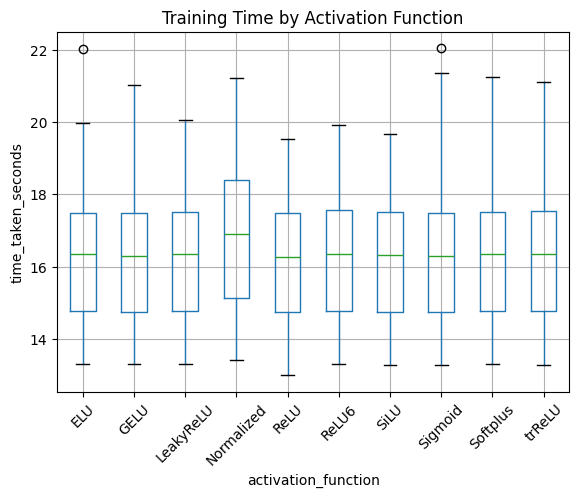

C:\Users\artem\AppData\Local\Temp\ipykernel_31628\3774945826.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(activation_col)[time_col]


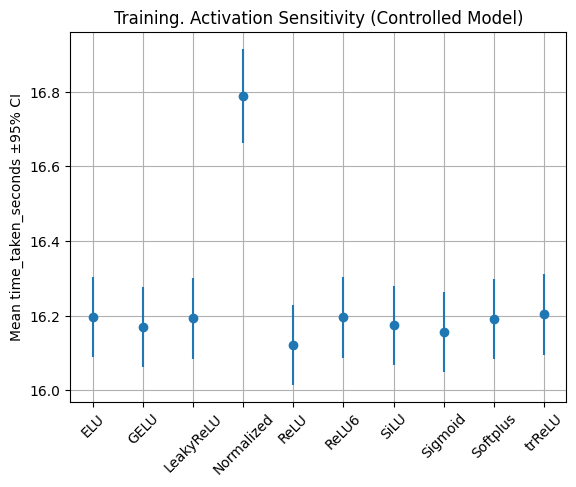

In [170]:
activation_sensitivity_analysis(
    combined_acrgnn_activationFunction,
    type="Training",
    time_col="time_taken_seconds",
    activation_col="activation_function",
    controls=["layer", "hidden_dimension", "learning_rate", "key"],
    robust=True,
    use_log=True,
    plot=True
)

c:\Users\artem\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,



Tukey HSD Post-hoc
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1     group2   meandiff p-adj   lower  upper  reject
-----------------------------------------------------------
       ELU       GELU   0.0207    1.0 -0.3127  0.354  False
       ELU  LeakyReLU  -0.0282    1.0 -0.3615 0.3052  False
       ELU Normalized   0.0494    1.0 -0.2839 0.3828  False
       ELU       ReLU   0.0447    1.0 -0.2886  0.378  False
       ELU      ReLU6   0.0723 0.9996  -0.261 0.4057  False
       ELU       SiLU  -0.0054    1.0 -0.3387  0.328  False
       ELU    Sigmoid  -0.0124    1.0 -0.3457 0.3209  False
       ELU   Softplus   0.1379 0.9518 -0.1954 0.4712  False
       ELU     trReLU  -0.0173    1.0 -0.3506  0.316  False
      GELU  LeakyReLU  -0.0488    1.0 -0.3821 0.2845  False
      GELU Normalized   0.0288    1.0 -0.3045 0.3621  False
      GELU       ReLU   0.0241    1.0 -0.3092 0.3574  False
      GELU      ReLU6   0.0517    1.0 -0.2816  0.385  False
      GELU       SiL

<Figure size 640x480 with 0 Axes>

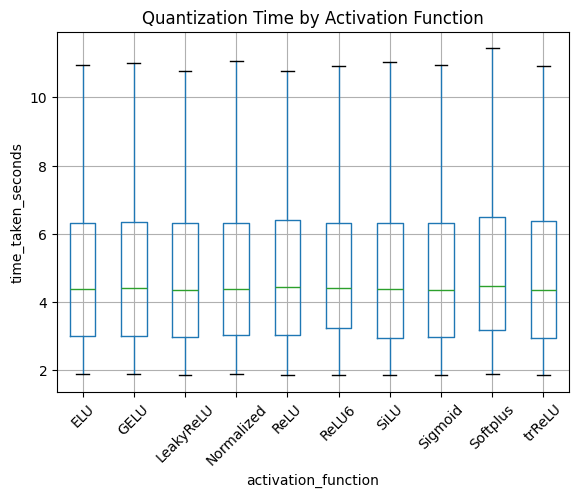

C:\Users\artem\AppData\Local\Temp\ipykernel_31628\3774945826.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(activation_col)[time_col]


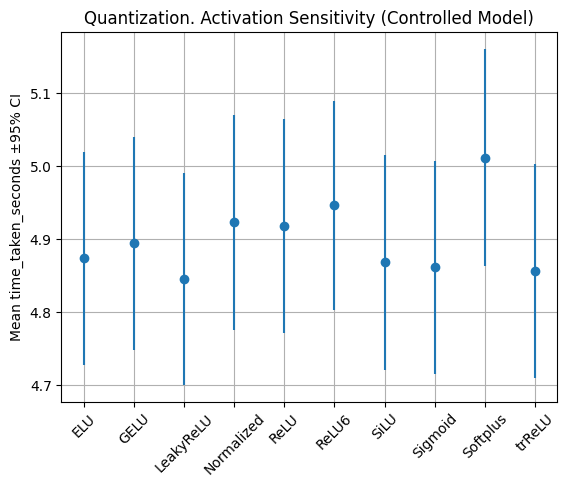

In [171]:
activation_sensitivity_analysis(
    combined_acrgnn_activationFunction_quantized,
    type="Quantization",
    time_col="time_taken_seconds",
    activation_col="activation_function",
    controls=["layer", "hidden_dimension", "learning_rate", "key"],
    robust=True,
    use_log=True,
    plot=True
)